# Schnitt-Extraktion aus axon_logger-MongoDB-JSON

**Vertraulichkeitshinweis:** Dieses Notebook verarbeitet Maschinen-, Prozess- und Werkstueckdaten
aus dem PTW-Versuchsaufbau (Hermle C32U / SINUMERIK 840D sl, Kistler-Kraftmessplatte). Die gesamte
Verarbeitung laeuft lokal -- es findet keine Netzwerkuebertragung statt. Bitte Notebook-Outputs
(Pfade, Seriennummern in `workpiecedata`) vor externer Weitergabe pruefen.

**Ziel:** Aus dem als MongoDB-Export vorliegenden JSON (`axon_logger_ptw_Lev022_raw.json`) werden
die Kraftdaten (`force_0/1/2`, 20 kHz) und die Achsdaten (Spindel + Vorschubachsen, 250 Hz, aus
`sensortype == "machine"`) extrahiert, in einzelne Schnitte segmentiert (4 Schnitte je Block,
getrennt durch Spindel-/Vorschubstopp) und je Schnitt als CSV (SinuTrace-Stil) exportiert.
Zusaetzlich wird pro Schnitt ein winkelaufgeloestes Radialkraft-Profil an der Schneidkante
berechnet (Basis fuer die spaetere $a_E/D$-Schaetzung).

**Segmentierungslogik (mit dir abgestimmt):**
- Bloecke = zusammenhaengende Force-Bursts >= `min_block_duration_s`.
- Einzelne Schnitte innerhalb eines Blocks = Richtungsumkehr der dominanten Vorschubachse
  (axis4/5/6), da die Spindel innerhalb eines 4er-Blocks durchgehend laeuft.
- Export nur Spindel (axis0) + Vorschubachsen (axis4, axis5, axis6) -- nicht alle 9 Achsen.


In [3]:
import sys, warnings
sys.path.insert(0, '.')  # kienzle_utils.py und cnc_cut_extractor.py im selben Verzeichnis

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.kienzle_utils import MillingSignalUtils as MSU
from src.cnc_cut_extractor import CNCCutExtractor

pd.set_option('display.width', 140)
%matplotlib inline


## 1. Pipeline instanziieren und JSON laden

Alle wichtigen Parameter (ADC-Bittiefe/Spannungsbereich, Anzahl Winkel-/Kraft-Samples,
Achs-Zuordnung, Segmentierungs-Schwellwerte) sind Konstruktor-Argumente -- fuer eine andere
Maschine/Messkette hier anpassen.

In [ ]:
ex = CNCCutExtractor(
    json_path="./../data/Hermle/20260701_C45_y/axon_logger_ptw_Lev028.raw.json",

    #json_path="./data/Hermle/20260701_C45_y/axon_logger_ptw_Lev028_raw.json",
    output_dir="./schnitte",
    spindle_axis_index=0,         # axis0 = Spindel (0-360 deg, Drehzahl ~konstant waehrend Schnitt)
    feed_axis_indices=(4, 5, 6),  # aktive Vorschubachsen laut Stichprobenanalyse
    cuts_per_block=4,             # nur fuer Plausibilitaets-Warnung, kein hartes Limit
    n_angle_samples=1000,         # Ziel-Abtastzahl Winkel (hochinterpoliert)
    n_force_samples=1000,         # Ziel-Abtastzahl Kraft (heruntersinterpoliert)
    adc_bits=16,                  # ADC-Aufloesung
    adc_v_range=10.0,             # ADC-Spannungsbereich (+/-10V, bipolar)
    adc_bipolar=True,
    min_block_duration_s=3.0,     # kuerzere Force-Bursts = Leerlauf-Heartbeat, kein Schnitt
    reversal_smooth_window=15,    # Glaettung vor Richtungsumkehr-Erkennung (~60ms bei 250Hz)
    reversal_prominence_frac=0.1, # Mindest-Prominenz eines Umkehrpunkts (Anteil der Spannweite)
    min_feed_range=2.0,           # Achse gilt erst ab dieser Positions-Spannweite als "bewegt"
)
ex.load()


FileNotFoundError: [Errno 2] No such file or directory: './data/Hermle/20260701_C45_y/axon_logger_ptw_Lev028.raw.json'

## 2. Bloecke erkennen (Diagnose)

Ein Block entspricht einem zusammenhaengenden Force-Aufnahme-Fenster >= `min_block_duration_s`.
Kurze 1s-Bursts (Leerlauf-Heartbeat des Loggers) werden verworfen.

In [3]:
blocks = ex.detect_blocks()
for i, b in enumerate(blocks, start=1):
    print(f"Block {i}: t = {b['t_start']:.2f} .. {b['t_end']:.2f} s  (Dauer {b['t_end']-b['t_start']:.2f} s)")


[detect_blocks] 19 Force-Bursts gefunden, 8 davon >= 3.0s (als Bearbeitungsbloecke gewertet).
Block 1: t = 41.00 .. 52.00 s  (Dauer 11.00 s)
Block 2: t = 62.00 .. 72.00 s  (Dauer 10.00 s)
Block 3: t = 262.00 .. 272.00 s  (Dauer 10.00 s)
Block 4: t = 354.00 .. 374.00 s  (Dauer 20.00 s)
Block 5: t = 435.00 .. 445.00 s  (Dauer 10.00 s)
Block 6: t = 465.00 .. 476.00 s  (Dauer 11.00 s)
Block 7: t = 537.00 .. 547.00 s  (Dauer 10.00 s)
Block 8: t = 738.00 .. 759.00 s  (Dauer 21.00 s)


## 3. Schnitt-Segmentierung visuell pruefen

Bevor der komplette Lauf gestartet wird: fuer einen Beispiel-Block die dominante
Vorschubachsen-Position plus die erkannten Richtungsumkehr-Punkte (= Schnittgrenzen) plotten.
Falls die Erkennung nicht plausibel aussieht (z.B. zu viele/zu wenige Schnitte), hier
`reversal_prominence_frac` bzw. `reversal_smooth_window` anpassen.

4 Schnitte erkannt: [(354.0, 358.4), (358.4, 360.19), (360.19, 371.19), (371.19, 374.0)]


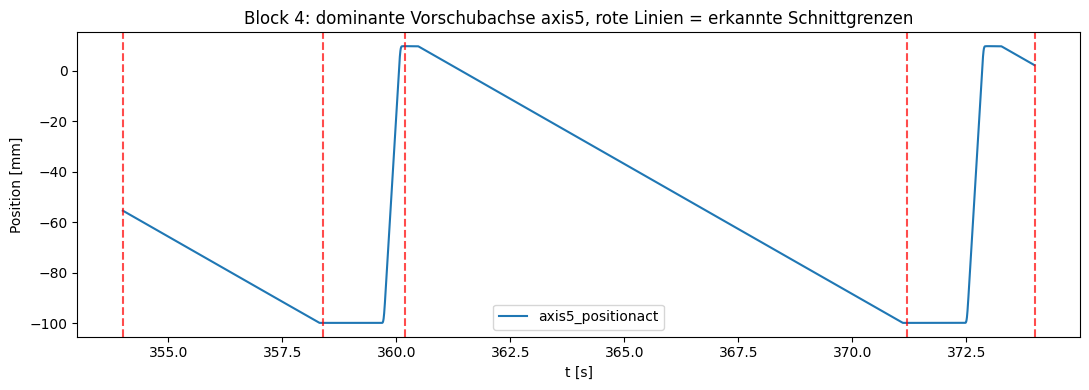

In [4]:
block_id = 4  # zum Durchprobieren anpassen (siehe Liste oben)
block = blocks[block_id - 1]
cuts, msgs = ex.detect_cuts_in_block(block)
for m in msgs:
    print("Hinweis:", m)
print(f"{len(cuts)} Schnitte erkannt:", [(round(a,2), round(b,2)) for a, b in cuts])

mdf = ex.machine_frame(block["t_start"], block["t_end"])
ranges = {ai: mdf[f"axis{ai}_positionact"].max() - mdf[f"axis{ai}_positionact"].min()
          for ai in ex.feed_axis_indices}
dom_axis = max(ranges, key=ranges.get)

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(mdf["t"], mdf[f"axis{dom_axis}_positionact"], label=f"axis{dom_axis}_positionact")
for t0, t1 in cuts:
    ax.axvline(t0, color="red", linestyle="--", alpha=0.7)
ax.axvline(cuts[-1][1], color="red", linestyle="--", alpha=0.7)
ax.set_xlabel("t [s]"); ax.set_ylabel("Position [mm]")
ax.set_title(f"Block {block_id}: dominante Vorschubachse axis{dom_axis}, rote Linien = erkannte Schnittgrenzen")
ax.legend(); plt.tight_layout(); plt.show()


## 4. Komplette Pipeline ausfuehren

Segmentiert alle Bloecke, extrahiert jeden Schnitt und schreibt je Schnitt zwei CSV-Dateien
nach `output_dir`:

- `Schnitt_blockNN_cutMM.csv` -- Rohsignale (Kraft in Volt + Achsstrom/-position), SinuTrace-Stil
- `Schnitt_blockNN_cutMM_radialforce_by_angle.csv` -- Summe/Mittelwert der Radialkraft je 1-deg-Winkel-Bin

Warnungen (z.B. abweichende Schnittanzahl, fehlende Machine-Daten im Fenster) werden protokolliert,
brechen den Lauf aber nicht ab.

In [5]:
with warnings.catch_warnings(record=True) as wlist:
    warnings.simplefilter("always")
    summary = ex.run()
    for w in wlist:
        print("WARNUNG:", w.message)

summary


[detect_blocks] 19 Force-Bursts gefunden, 8 davon >= 3.0s (als Bearbeitungsbloecke gewertet).


[run] 8 Bloecke, 24 Schnitte extrahiert. CSVs liegen in: /mnt/user-data/outputs/schnitte
WARNUNG: [Block 1] Achtung: 3 Schnitte erkannt (dominante Achse axis5, Spannweite 109.55), erwartet wurden 4. Bitte reversal_prominence_frac / reversal_smooth_window pruefen oder Bloecke manuell inspizieren.
WARNUNG: [Block 2] Achtung: 1 Schnitte erkannt (dominante Achse axis5, Spannweite 90.09), erwartet wurden 4. Bitte reversal_prominence_frac / reversal_smooth_window pruefen oder Bloecke manuell inspizieren.
WARNUNG: [Block 3] Achtung: 1 Schnitte erkannt (dominante Achse axis6, Spannweite 403.26), erwartet wurden 4. Bitte reversal_prominence_frac / reversal_smooth_window pruefen oder Bloecke manuell inspizieren.
WARNUNG: [Block 5] Keine Vorschubachse bewegt sich um mehr als min_feed_range=2.0 (groesste Spannweite: axis6 = 0.000) -- vermutlich reiner Spindel-Leerlauf oder zu kurzes/verrauschtes Machine-Datenfenster. Fallback: gleichmaessige Teilung in 4 Schnitte.
WARNUNG: [Block 6] Keine Vorschub

,block_id,cut_id,t_start_s,t_end_s,duration_s,n_rows_raw,csv_path,n_warnings
0,1,1,41.000,43.796,2.796,55921,/mnt/user-data/outputs/schnitte/Schnitt_block0...,0
1,1,2,43.796,45.548,1.752,35041,/mnt/user-data/outputs/schnitte/Schnitt_block0...,0
2,1,3,45.548,52.000,6.452,129040,/mnt/user-data/outputs/schnitte/Schnitt_block0...,0
3,2,1,62.000,72.000,10.000,200000,/mnt/user-data/outputs/schnitte/Schnitt_block0...,0
4,3,1,262.000,272.000,10.000,200000,/mnt/user-data/outputs/schnitte/Schnitt_block0...,0
5,4,1,354.000,358.396,4.396,87921,/mnt/user-data/outputs/schnitte/Schnitt_block0...,0
6,4,2,358.396,360.188,1.792,35841,/mnt/user-data/outputs/schnitte/Schnitt_block0...,0
7,4,3,360.188,371.192,11.004,220081,/mnt/user-data/outputs/schnitte/Schnitt_block0...,0
8,4,4,371.192,374.000,2.808,56160,/mnt/user-data/outputs/schnitte/Schnitt_block0...,0
9,5,1,435.000,437.500,2.500,50001,/mnt/user-data/outputs/schnitte/Schnitt_block0...,0


## 5. Beispiel-Schnitt inspizieren

Rohsignal-CSV eines Schnitts laden (identisch zum Format der angehaengten `Trace_*.csv`-Referenz)
und die Kraft- sowie Achssignale plotten.

block_id                                                      4
cut_id                                                        3
t_start_s                                               360.188
t_end_s                                                 371.192
duration_s                                               11.004
n_rows_raw                                               220081
csv_path      /mnt/user-data/outputs/schnitte/Schnitt_block0...
n_warnings                                                    0
Name: 7, dtype: object


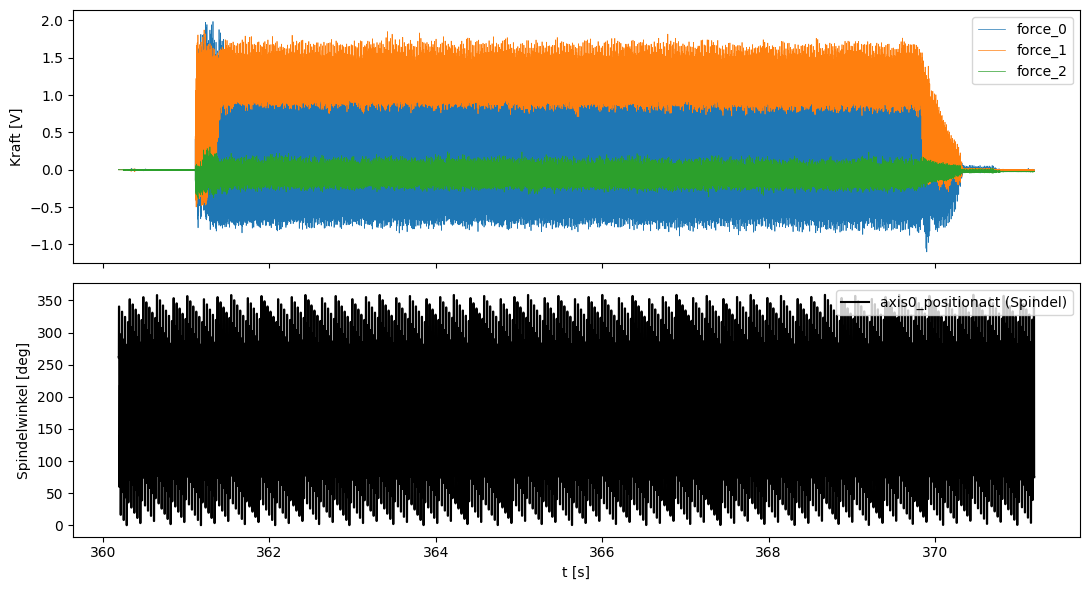

In [6]:
row = summary.iloc[(summary["duration_s"]).idxmax()]  # laengster Schnitt zur Anschauung
print(row)

df_cut = pd.read_csv(row["csv_path"])
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
axes[0].plot(df_cut["time"], df_cut["force_0"], label="force_0", lw=0.5)
axes[0].plot(df_cut["time"], df_cut["force_1"], label="force_1", lw=0.5)
axes[0].plot(df_cut["time"], df_cut["force_2"], label="force_2", lw=0.5)
axes[0].set_ylabel("Kraft [V]"); axes[0].legend(loc="upper right")

axes[1].plot(df_cut["time"], df_cut["axis0_positionact"], color="black", label="axis0_positionact (Spindel)")
axes[1].set_ylabel("Spindelwinkel [deg]"); axes[1].set_xlabel("t [s]"); axes[1].legend(loc="upper right")
plt.tight_layout(); plt.show()


## 6. Winkel-Interpolation und Radialkraft-Profil

Fuer denselben Schnitt: die auf `n_angle_samples` hochinterpolierte Spindelposition, die auf
`n_force_samples` heruntersinterpolierte Kraft, sowie das daraus abgeleitete Radialkraft-Profil
ueber dem Spindelwinkel (Summe je 1-deg-Bin, ueber alle im Schnitt enthaltenen Umdrehungen).

Das Profil zeigt den Werkzeugeingriffsbereich: der Winkelbereich mit deutlich von Null
verschiedener (positiver bzw. negativer) Radialkraft entspricht dem Eingriffswinkel des
Fraeswerkzeugs und ist die Grundlage fuer die spaetere aE/D-Schaetzung (vgl.
`MillingSignalUtils.engagement_angle_from_ae` / `entry_angle_from_ae` in kienzle_utils.py).

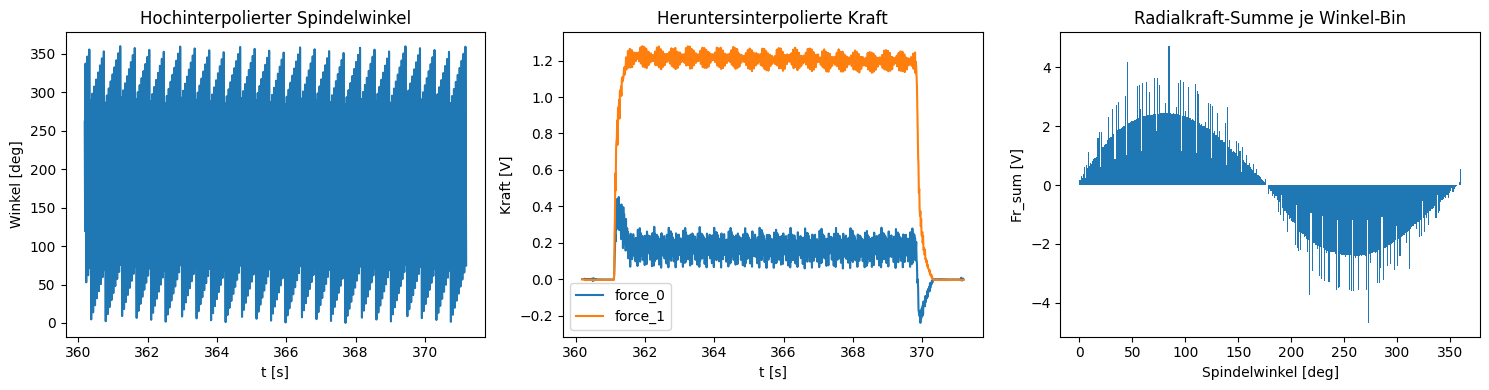

,angle_deg,Fr_sum,Fr_mean,count
count,360.000000,360.000000,360.000000,360.000000
mean,180.000000,0.023453,0.008934,2.777778
std,104.067286,1.981601,0.734310,0.772476
min,0.500000,-4.678439,-1.201360,1.000000
25%,90.250000,-1.752141,-0.657773,2.000000
50%,180.000000,0.001664,-0.000357,3.000000
75%,269.750000,1.870801,0.662487,3.000000
max,359.500000,4.711415,1.225995,4.000000


In [7]:
cut_idx = int(row.name)  # gleicher Schnitt wie oben
result = ex.results[cut_idx]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(np.linspace(result.t_start, result.t_end, ex.n_angle_samples), result.angle_deg)
axes[0].set_title("Hochinterpolierter Spindelwinkel"); axes[0].set_xlabel("t [s]"); axes[0].set_ylabel("Winkel [deg]")

axes[1].plot(np.linspace(result.t_start, result.t_end, ex.n_force_samples), result.force_ds["force_0"], label="force_0")
axes[1].plot(np.linspace(result.t_start, result.t_end, ex.n_force_samples), result.force_ds["force_1"], label="force_1")
axes[1].set_title("Heruntersinterpolierte Kraft"); axes[1].set_xlabel("t [s]"); axes[1].set_ylabel("Kraft [V]"); axes[1].legend()

prof = result.radial_force_profile
axes[2].bar(prof["angle_deg"], prof["Fr_sum"], width=1.0)
axes[2].set_title("Radialkraft-Summe je Winkel-Bin"); axes[2].set_xlabel("Spindelwinkel [deg]"); axes[2].set_ylabel("Fr_sum [V]")
plt.tight_layout(); plt.show()

prof.describe()


## 7. Naechste Schritte

- **Physikalische Kalibrierung:** Aktuell liefert `MSU.adc_counts_to_voltage()` nur Volt, keine
  Newton. Sobald die Kistler-Ladungsverstaerker-Empfindlichkeit (pC/N) und der
  Verstaerkungsfaktor bekannt sind, in `extract_cut()` nach der ADC-Konvertierung einen
  Kalibrierfaktor `V_to_N` einbauen (bzw. `kienzle_utils.py` um eine entsprechende Funktion
  ergaenzen).
- **Kienzle-Normalisierung / Feature-Extraktion:** Die bestehenden Funktionen in
  `kienzle_utils.py` (`spindle_torque`, `max_Mc`, `correct_no_load`, ...) koennen direkt auf
  `result.raw_table` bzw. die heruntersinterpolierten Kanaele (`result.force_ds`) angewendet
  werden, um die im aE-Schaetzer verwendeten physik-basierten Merkmale (RMS, Crest-Faktor,
  Tooth-Pass-Spektralenergie, Kienzle-Residuum) zu berechnen.
- **Segmentierungs-Feintuning:** Die Warnungen aus Schritt 4 zeigen, bei welchen Bloecken die
  Vorschub-Richtungsumkehr nicht exakt 4 Schnitte ergeben hat. Betroffene Bloecke einzeln mit
  Schritt 3 visuell pruefen und ggf. `reversal_prominence_frac` / `reversal_smooth_window` /
  `min_feed_range` pro Block anpassen, bevor die finalen CSVs fuer das Training verwendet werden.
- **MongoDB-Ingestion:** Die erzeugten Schnitt-CSVs bzw. die daraus abgeleiteten Merkmale koennen
  anschliessend in `PTW_ITAM_ae` geladen werden (offener Punkt aus der Streamlit-Pipeline).
